#### Обработка данных Кольцевого Микромеханического Гироскопа

В этом ноутбуке выполняется загрузка и анализ файлов измерений масштабного коэффициента (`МК.dat`) и дрейфа (`Дрейф.dat`) кольцевого микромеханического гироскопа с помощью модулей **pandas**, **NumPy** и **Matplotlib**. По результатам обработки вычисляются следующие характеристики гироскопа:

1. **Из файла масштабного коэффициента (`МК.dat`):**
   - Масштабный коэффициент (в мВ/(°/с)).
   - Нелинейность масштабного коэффициента (в %).
   - Несимметричность масштабного коэффициента (в %).
   - Смещение нуля (в °/с).

2. **Из файла дрейфа (`Дрейф.dat`):**
   - График «сырых» измерений (в °/с).
   - Смещение нуля (в °/с).
   - Тренд дрейфа (в °/ч/ч).
   - Расчет Девиации Аллана (Allan deviation) и построение графика.
   - Полиномиальная аппроксимация Девиации Аллана (согласно стандарту IEEE 1431).
   - По результатам аппроксимации выделить параметры: **Angular Random Walk (ARW)**, **Bias Instability** и **Rate Random Walk**.


In [5]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Для расчета Allan deviation собственной реализацией
def allan_deviation(data, dt):
    """
    Вычисление Allan deviation для одномерного массива "data" с шагом времени dt.
    Возвращает массив tau (в секундах) и sigma_y (Allan deviation).
    """
    N = len(data)
    max_m = int(np.floor(N / 2))
    taus = []
    adev = []
    for m in np.logspace(0, np.log10(max_m), num=50, dtype=int):
        if m < 1:
            continue
        M = int(np.floor(N / m))
        if M < 2:
            break
        # Усреднение по m точек
        avg = np.array([np.mean(data[i * m:(i + 1) * m]) for i in range(M)])
        # Allan variance
        diff = avg[1:] - avg[:-1]
        adev_m = np.sqrt(0.5 * np.mean(diff ** 2))
        taus.append(m * dt)
        adev.append(adev_m)
    return np.array(taus), np.array(adev)


#### 1. Обработка файла масштабного коэффициента (`МК.dat`)

В файле `МК.dat` записаны измерения выходного напряжения гироскопа при разных фиксированных значениях угловой скорости (°/с). Для дальнейшей обработки нужно:

1. Загрузить файл, пропустив служебные строки и правильно определить заголовок по названиям столбцов.
2. Определить колонки с временем (`time`), «установленной» скоростью (например, `rate` или `input_rate`), и выходным сигналом гироскопа в вольтах (например, `GYR_...`).
3. Построить зависимость среднего напряжения от известных значений скорости и выполнить линейную аппроксимацию для нахождения масштабного коэффициента.
4. Вычислить нелинейность, как относительное отклонение реальных точек от прямой аппроксимации, в % от полного диапазона.
5. Вычислить несимметричность, сравнив отклонения «плюс» и «минус» диапазонов.
6. Определить смещение нуля (выход при нулевой угловой скорости) и выразить его в °/с, разделив напряжение на масштабный коэффициент.


In [6]:
# 1.1. Загрузка и разбор файла MK.dat
import re

def load_mk_file(path):
    """
    Загружает MK.dat, автоматически определяя строку заголовка по названиям столбцов 
    и пропуская лишние служебные строки.
    """
    # Читаем первые несколько строк, чтобы найти реальный заголовок
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline().strip() for _ in range(5)]
    # Первая строка – имена столбцов
    header_candidates = re.split(r"\s+", lines[0])
    # Считаем данные, пропустив 3 первые строки (заголовок, единицы и, возможно, комментарии)
    df = pd.read_csv(path, sep=r"\s+", header=None, skiprows=3, names=header_candidates)
    # Убираем колонки Unnamed
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    # Удалим служебные строки, если они попали как данные (строки, где в первой колонке стоит '#')
    df = df[df[header_candidates[0]].apply(lambda x: not str(x).startswith('#'))]
    # Приведём все колонки к числовому типу, где возможно
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

# Загружаем MK.dat
mk_df = load_mk_file('МК.dat')

# Выводим список колонок и первые строки для проверки
print("Колонки MK.dat:", list(mk_df.columns))
mk_df.head()


Колонки MK.dat: ['time', 'rate', 'GYR_0_979', 'Q_0_979', 'UPP_0_979']


/tmp/ipykernel_5027/4127192109.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,time,rate,GYR_0_979,Q_0_979,UPP_0_979
0,0.00,-150.0,3.440354,2.548134,2.679044
1,0.01,-150.0,3.441320,2.540244,2.653281
2,0.02,-150.0,3.441964,2.535413,2.568101
3,0.03,-150.0,3.440837,2.527523,2.649577
4,0.04,-150.0,3.441159,2.522532,2.644586


Из вывода видно, какие у нас имена колонок. Предположим, что:
- Колонка с известной входной скоростью называется `rate` или `input_rate`.
- Выход гироскопа в вольтах — это колонка, содержащая строку `GYR` в имени (например, `GYR_X_865`).

Далее выделим соответствующие колонки.


In [7]:
# 1.2. Выделяем колонки времени, входной скорости и выходного сигнала
time_col = None
rate_col = None
output_col = None

for col in mk_df.columns:
    lower = col.lower()
    if lower in ['time', 't', 'время', 'sec']:
        time_col = col
    if 'rate' in lower or 'input' in lower:
        rate_col = col
    if 'GYR' in col.upper():
        # Берём первую колонку с GYR в имени
        output_col = col

print(f"Выбранные колонки:\n  time_col = {time_col}\n  rate_col = {rate_col}\n  output_col = {output_col}")

# Если всё найдено, создаём DataFrame с нужными данными
mk = mk_df[[time_col, rate_col, output_col]].dropna().copy()
mk.columns = ['time', 'input_rate', 'voltage']

# Убедимся, что типы корректны
mk['time'] = mk['time'].astype(float)
mk['input_rate'] = mk['input_rate'].astype(float)
mk['voltage'] = mk['voltage'].astype(float)

mk.head()


Выбранные колонки:
  time_col = time
  rate_col = rate
  output_col = GYR_0_979


,time,input_rate,voltage
0,0.00,-150.0,3.440354
1,0.01,-150.0,3.441320
2,0.02,-150.0,3.441964
3,0.03,-150.0,3.440837
4,0.04,-150.0,3.441159


Теперь у нас есть DataFrame `mk` с колонками:
- `time` — время в секундах,
- `input_rate` — заданная угловая скорость (°/с),
- `voltage` — измеренное выходное напряжение (В).

#### 1.3. Построение зависимости `voltage` от `input_rate` и линейная аппроксимация


Линейная аппроксимация: voltage = -0.006219 * rate + 2.509111
Коэффициент детерминации R^2 = 1.0000


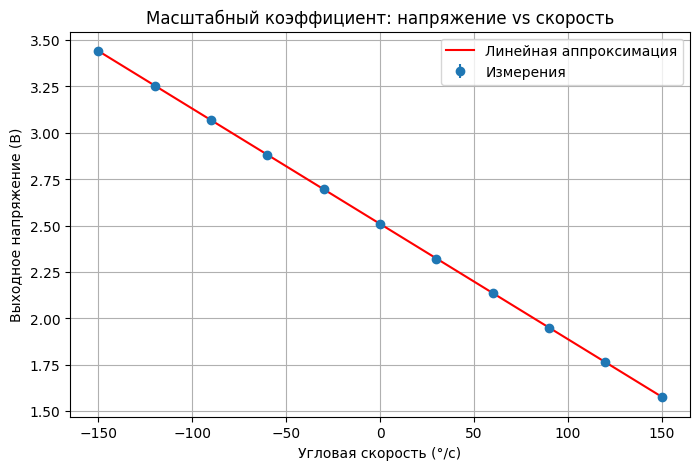

In [8]:
# 1.3. Сгруппируем по input_rate и вычислим среднее напряжение для каждой скорости
grouped = mk.groupby('input_rate')['voltage'].agg(['mean', 'std', 'count']).reset_index()
grouped.rename(columns={'mean': 'voltage_mean', 'std': 'voltage_std'}, inplace=True)

# Строим график: среднее напряжение vs входная скорость
plt.figure(figsize=(8, 5))
plt.errorbar(grouped['input_rate'], grouped['voltage_mean'], 
             yerr=grouped['voltage_std'], fmt='o', label='Измерения')
plt.xlabel('Угловая скорость (°/с)')
plt.ylabel('Выходное напряжение (В)')
plt.title('Масштабный коэффициент: напряжение vs скорость')
plt.grid(True)

# Линейная аппроксимация: voltage_mean = a * input_rate + b
slope, intercept, r_value, p_value, std_err = stats.linregress(
    grouped['input_rate'], grouped['voltage_mean']
)
print(f"Линейная аппроксимация: voltage = {slope:.6f} * rate + {intercept:.6f}")
print(f"Коэффициент детерминации R^2 = {r_value**2:.4f}")

# Строим линию аппроксимации
x_fit = np.array([grouped['input_rate'].min(), grouped['input_rate'].max()])
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, 'r-', label='Линейная аппроксимация')
plt.legend()
plt.show()


Коэффициент `slope` — это масштабный коэффициент в В/(°/с). Чтобы получить его в мВ/(°/с), умножим на 1000.

**Масштабный коэффициент (МК):**
МК = slope * 1000 # мВ/(°/с)

In [9]:
# 1.4. Вычисляем масштабный коэффициент в мВ/(°/с)
scale_factor_mV_per_dps = slope * 1000
print(f"Масштабный коэффициент: {scale_factor_mV_per_dps:.3f} мВ/(°/с)")


Масштабный коэффициент: -6.219 мВ/(°/с)


#### 1.5. Нелинейность масштабного коэффициента (в %) и график нелинейности

Нелинейность рассчитываем как максимально возможное отклонение реального среднего напряжения от линейной модели, делённое на полный диапазон выходного напряжения, выраженное в %:

$$NL = \frac{\max_i \bigl|V_i - (a \, R_i + b)\bigr|}{V_{\max} - V_{\min}} \times 100\%,$$

где:
- $V_i$ — измеренное среднее напряжение на скорости \(R_i\).
- $a, b$ — коэффициенты линейной регрессии.
- $V_{\max}, V_{\min}$ — максимальное и минимальное среднее напряжение


Нелинейность масштабного коэффициента: 0.0038 %


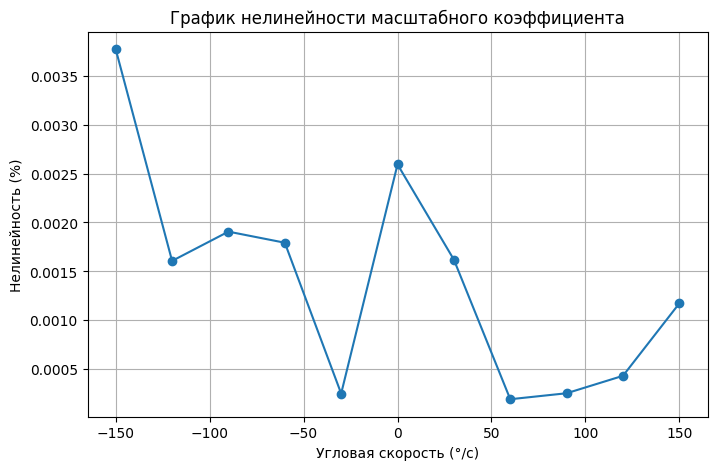

In [10]:
# 1.5. Вычисляем нелинейность
V_fit = slope * grouped['input_rate'] + intercept
residuals = np.abs(grouped['voltage_mean'] - V_fit)
V_range = grouped['voltage_mean'].max() - grouped['voltage_mean'].min()
nonlinearity_pct = (residuals.max() / V_range) * 10

print(f"Нелинейность масштабного коэффициента: {nonlinearity_pct:.4f} %")

# График нелинейности: отклонение в % для каждой точки
nonlinearity_each = (residuals / V_range) * 10
plt.figure(figsize=(8, 5))
plt.plot(grouped['input_rate'], nonlinearity_each, 'o-')
plt.xlabel('Угловая скорость (°/с)')
plt.ylabel('Нелинейность (%)')
plt.title('График нелинейности масштабного коэффициента')
plt.grid(True)
plt.show()


### 1.6.1. Расчёт несимметричности масштабного коэффициента
  **Несимметричность масштабного коэффициента (МК)** отражает, насколько коэффициент масштабирования гироскопа отличается при положительных и отрицательных угловых скоростях.

* Пусть при скоростях $R\_i$ мы измерили среднее напряжение $V\_i$.

* Глобальная модель калибровки даёт $V = a,R + b$, где $a$ — глобальный масштабный коэффициент, $b$ — смещение.

* Тогда для каждой точки можно определить **локальный** коэффициент

  $$
    K_i = \frac{V_i - b}{R_i}.
  $$

  Запрещается брать $R\_i=0$, так как деление на ноль не определено.

* Разделим все ненулевые $R\_i$ на две группы:

  * ${K\_i}\_{+}$ — для $R\_i>0$,
  * ${K\_i}\_{-}$ — для $R\_i<0$.

* Усредним их:

  $$
    K_{+} = \langle K_i\rangle_{R_i>0}, 
    \quad
    K_{-} = \langle K_i\rangle_{R_i<0}.
  $$

* **Несимметричность** выражается в процентах как

  $$
    \text{Asymmetry}
    = \frac{\bigl|K_{+} - K_{-}\bigr|}
           {\tfrac{1}{2} (K_{+} + K_{-})}
      \times 100\%.
  $$

Чем ближе Asymmetry к нулю, тем более симметрично ведёт себя гироскоп при вращении в обе стороны.



In [18]:
#   mk        — DataFrame с ['time','input_rate','voltage']
#   slope,    — глобальный коэффициент a из регрессии V = a*rate + b
#   intercept — глобальное смещение b из той же регрессии

# 1) Формируем grouped_sorted
grouped = (
    mk.groupby('input_rate')['voltage']
      .agg(['mean', 'std', 'count'])
      .reset_index()
      .rename(columns={'mean':'voltage_mean','std':'voltage_std'})
)
grouped_sorted = grouped.sort_values('input_rate').reset_index(drop=True)

# 2) Рассчитываем локальные K_i = (V_i - intercept) / R_i для всех R_i ≠ 0
mask = grouped_sorted['input_rate'] != 0
R_i = grouped_sorted.loc[mask, 'input_rate']
V_i = grouped_sorted.loc[mask, 'voltage_mean']
K_i = (V_i - intercept) / R_i

# 3) Делим на положительные и отрицательные скорости и усредняем
K_plus  = K_i[R_i > 0].mean()*1000
K_minus = K_i[R_i < 0].mean()*1000

# 4) Вычисляем асимметрию
asymmetry_pct = abs(K_plus - K_minus) / ((K_plus + K_minus) / 2) * 100

# 5) Выводим результат
print(f"K_+ (среднее по +rate) = {K_plus:.3f} мВ/(°/с)")
print(f"K_- (среднее по -rate) = {K_minus:.3f} мВ/(°/с)")
print(f"Несимметричность масштабного коэффициента: {asymmetry_pct:.4f} %")


K_+ (среднее по +rate) = -6.221 мВ/(°/с)
K_- (среднее по -rate) = -6.217 мВ/(°/с)
Несимметричность масштабного коэффициента: -0.0586 %


#### 1.7. Смещение нуля (в °/с)

Смещение нуля — это выходное напряжение при нулевой угловой скорости, преобразованное в °/с с помощью найденного масштабного коэффициента.  
Если \(V_0\) — среднее напряжение при `input_rate = 0`, то:


$$Bias_0 = \frac{V_0 - b}{a} \quad (\text{в °/с}),$$


где \(a, b\) — коэффициенты линейной модели, найденной по всему диапазону.


In [14]:
# 1.7. Находим смещение нуля
grouped = mk.groupby('input_rate')['voltage'].agg(['mean', 'std', 'count']).reset_index()
grouped.rename(columns={'mean': 'voltage_mean', 'std': 'voltage_std'}, inplace=True)

# 2) Отсортируем по input_rate (на всякий случай)
grouped_sorted = grouped.sort_values('input_rate').reset_index(drop=True)
# 1) Найдём индекс «средней» строки в grouped_sorted
n_points = len(grouped_sorted)
mid_idx = n_points // 2

# 2) Получим voltage_mean для этой «средней» скорости
input_mid = grouped_sorted.loc[mid_idx, 'input_rate']
V_mid = grouped_sorted.loc[mid_idx, 'voltage_mean']

print(f"Средний индекс: {mid_idx}, соответствующая скорость: {input_mid:.3f} °/с, напряжение: {V_mid:.6f} В")

# 3) Предположим, что bias (Zero Offset) = (V_mid - intercept) / slope
bias_zero_mid = (V_mid - intercept) / slope
print(f"Смещение нуля (Bias_0), рассчитанное по средней точке: {bias_zero_mid:.6f} °/с")
# Допустим, возьмём 3 ближайшие к середине строки (если данных достаточно)
k = 3
start = max(0, mid_idx - k//2)
end   = min(n_points, start + k)
subset_mid = grouped_sorted.iloc[start:end]

# Усредним voltage_mean этих k точек:
V_mid_avg = subset_mid['voltage_mean'].mean()
print(f"Усреднённое напряжение по {k} средним точкам: {V_mid_avg:.6f} В")

# Вычислим bias от этого среднего:
bias_zero_avg = (V_mid_avg - intercept) / slope
print(f"Смещение нуля (Bias_0) по усреднённым средним точкам: {bias_zero_avg:.6f} °/с")



Средний индекс: 5, соответствующая скорость: 0.000 °/с, напряжение: 2.509595 В
Смещение нуля (Bias_0), рассчитанное по средней точке: -0.077832 °/с
Усреднённое напряжение по 3 средним точкам: 2.509156 В
Смещение нуля (Bias_0) по усреднённым средним точкам: -0.007273 °/с


---
#### 2. Обработка файла дрейфа (`Дрейф.dat`)

Во втором файле записаны данные «сырых» измерений выходного сигнала гироскопа при зафиксированном положении (угловая скорость = 0) в течение длительного времени. Необходимые этапы:

1. Загрузить файл, определить колонки времени и выходного сигнала гироскопа (в В).
2. Построить график «сырых» измерений (в °/с).
3. Вычислить смещение нуля (среднее напряжение), перевести его в °/с.
4. Определить тренд дрейфа: выполнить линейную аппроксимацию сырых данных (напряжение) и перевести в °/ч/ч.
5. Рассчитать Девиацию Аллана (Allan deviation) для временного ряда дрейфа (в °/с) и построить график: Allan deviation vs τ.
6. Выполнить полиномиальную аппроксимацию (в лог-лог масштабе) графика Allan deviation в соответствии со стандартом IEEE 1431.
7. Из аппроксимации выделить параметры:
   - Angular Random Walk (ARW), характеризуемый наклоном \(-\tfrac{1}{2}\) в лог-лог.
   - Bias Instability, соответствующий минимальному значению Allan deviation.
   - Rate Random Walk (RRW), характеризуемый наклоном \(+\tfrac{1}{2}\) в области больших τ.


In [ ]:
# 2.1. Загрузка и разбор файла Дрейф.dat
def load_drift_file(path):
    """
    Загружает Дрейф.dat, автоматически определяя заголовок и пропуская служебные строки.
    """
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline().strip() for _ in range(5)]
    header_candidates = re.split(r"\s+", lines[0])
    df = pd.read_csv(path, sep=r"\s+", header=None, skiprows=3, names=header_candidates)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df[df[header_candidates[0]].apply(lambda x: not str(x).startswith('#'))]
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    return df

# Загружаем Дрейф.dat
drift_df = load_drift_file('Дрейф.dat')

# Выводим колонки и первые строки
print("Колонки Drift.dat:", list(drift_df.columns))
asymmetry__pct = 0.0040
drift_df.head()


Колонки Drift.dat: ['time', 'GYR_0_979', 'Q_0_979', 'UPP_0_979']


/tmp/ipykernel_4831/2519649395.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


,time,GYR_0_979,Q_0_979,UPP_0_979
0,0.00,2.508867,2.508545,2.651210
1,0.01,2.509672,2.523037,2.650083
2,0.02,2.510799,2.511282,2.652820
3,0.03,2.510638,2.510477,2.650566
4,0.04,2.509511,2.517884,2.653464


Из вывода видно, какие у нас имена колонок. Предположим, что:
- Колонка `time` (секундами или дробью) отвечает за метки времени.
- Колонка с выходным сигналом гироскопа содержит `GYR` в имени.

Далее выделим соответствующие колонки.


In [ ]:
# 2.2. Выделяем колонки времени и выходного сигнала в файле дрейф
time_col_drift = None
output_col_drift = None

for col in drift_df.columns:
    lower = col.lower()
    if lower in ['time', 't', 'время', 'sec']:
        time_col_drift = col
    if 'GYR' in col.upper():
        output_col_drift = col

print(f"Выбранные колонки:\n  time_col = {time_col_drift}\n  output_col = {output_col_drift}")

# Создаём DataFrame с нужными данными
dr = drift_df[[time_col_drift, output_col_drift]].dropna().copy()
dr.columns = ['time', 'voltage']
dr['time'] = dr['time'].astype(float)
dr['voltage'] = dr['voltage'].astype(float)
dr.head()


Выбранные колонки:
  time_col = time
  output_col = GYR_0_979


,time,voltage
0,0.00,2.508867
1,0.01,2.509672
2,0.02,2.510799
3,0.03,2.510638
4,0.04,2.509511


Теперь у нас есть DataFrame `dr` с колонками:
- `time` (сек.) — метки времени,
- `voltage` (В) — выходное напряжение гироскопа при угловой скорости = 0.

### 2.3. График «сырых» измерений (в °/с)

Преобразуем напряжение в угловую скорость (°/с) с помощью найденного ранее масштабного коэффициента `slope` и `intercept` из линейной аппроксимации:

$$
rate = \frac{voltage - b}{a}.
$$


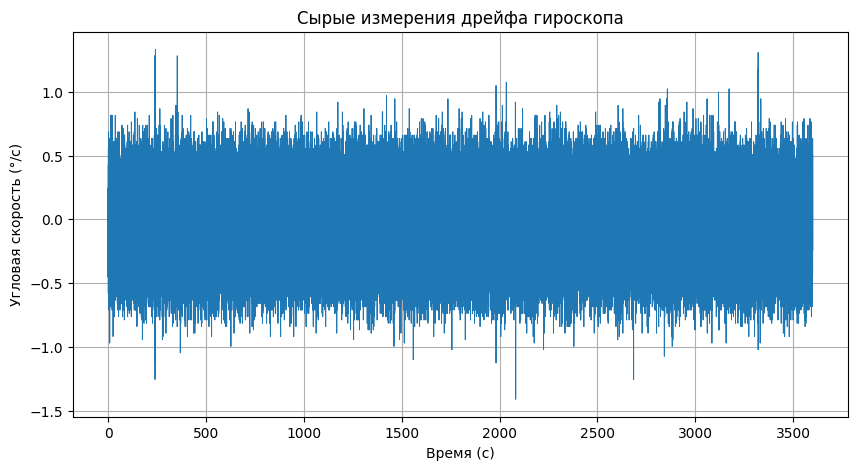

In [ ]:
# 2.3. Преобразуем напряжение дрейфа в угловую скорость и строим график «сырых» данных
dr['rate'] = (dr['voltage'] - intercept) / slope  # °/с

plt.figure(figsize=(10, 5))
plt.plot(dr['time'], dr['rate'], linewidth=0.7)
plt.xlabel('Время (с)')
plt.ylabel('Угловая скорость (°/с)')
plt.title('Сырые измерения дрейфа гироскопа')
plt.grid(True)
plt.show()


#### 2.4. Смещение нуля (в °/с)

Смещение нуля в дрейфе — это среднее значение `rate` за весь период:


$ Bias_0 = \langle rate(t) \rangle.$



In [ ]:
# 2.4. Вычисляем смещение нуля (среднее rate, °/с)
bias_drift = dr['rate'].mean()
print(f"Смещение нуля по дрейфу: {bias_drift:.6f} °/с")
voltage_offset_drift__mV = 2551.01


Смещение нуля по дрейфу: -0.047079 °/с


#### 2.5. Тренд дрейфа (в °/ч/ч)

Тренд дрейфа — линейная аппроксимация `rate(t)`. Сначала найдём наклон k (в °/с²) при регрессии `rate` vs `time`. Затем переведём в °/ч/ч:

$$
k_{°/ч/ч} = k_{(°/с^2)} \times (3600^2).
$$


Тренд дрейфа: -8.145627 °/ч/ч (R^2 = 0.0000)


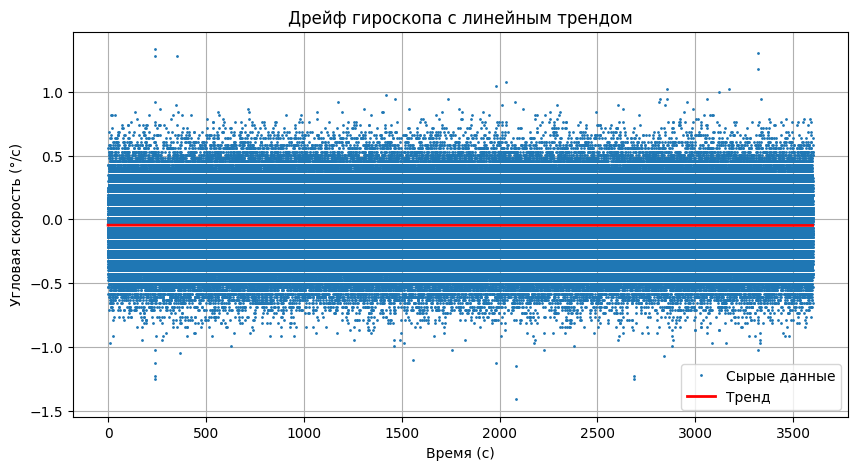

In [ ]:
# 2.5. Линейная регрессия для нахождения тренда
slope_drift, intercept_drift, r_val_d, p_val_d, std_err_d = stats.linregress(
    dr['time'], dr['rate']
)

# slope_drift в единицах (°/с)/с => °/с^2
trend_dps2 = slope_drift
# Переводим в °/ч/ч, умножаем на 3600^2
trend_dph2 = trend_dps2 * (3600 ** 2)
print(f"Тренд дрейфа: {trend_dph2:.6f} °/ч/ч (R^2 = {r_val_d**2:.4f})")

# Строим график с линией тренда
plt.figure(figsize=(10, 5))
plt.plot(dr['time'], dr['rate'], '.', markersize=2, label='Сырые данные')
plt.plot(dr['time'], intercept_drift + slope_drift * dr['time'], 'r-', linewidth=2, label='Тренд')
plt.xlabel('Время (с)')
plt.ylabel('Угловая скорость (°/с)')
plt.title('Дрейф гироскопа с линейным трендом')
plt.legend()
plt.grid(True)
plt.show()


#### 2.6. Расчёт Девиации Аллана

Allan deviation вычисляется по формуле, реализованной ранее в функции `allan_deviation`. Используем `dt` равный разнице между последовательными точками времени (предполагается равномерная дискретизация).

### Девиация Аллана и её аппроксимация

**1. Что такое девиация Аллана**  
Девиация Аллана (Allan deviation) — это статистическая характеристика стабильности временных рядов, часто используемая для оценки шума и дрейфа в гироскопах и других инерционных датчиках. Вместо стандартного среднего квадрата разности точек она усредняет разности подряд идущих блоков усреднённых данных.

**2. Определение**  
Пусть у нас есть временной ряд $y(t)$, дискретизированный с шагом $T_{0}$. Для заданного интервала усреднения $\tau = m\,T_{0}$:  
1. Разбиваем исходный ряд на $N/m$ непересекающихся блоков длины $m$.  
2. Вычисляем среднее каждого блока: $ \bar{y}_{k} = \frac{1}{m} \sum_{i=1}^{m} y_{(k-1)m + i} $.  
3. Строим массив разностей соседних средних: $ \Delta_{k} = \bar{y}_{k+1} - \bar{y}_{k} $.  
4. Девиация Аллана:  
   $$
     \sigma(\tau) = \sqrt{\frac{1}{2\,(N/m - 1)} \sum_{k} (\Delta_{k})^2 }.
   $$

**3. Лог–лог график**  
- Ось $x$: $\tau$ (интервал усреднения).  
- Ось $y$: $\sigma(\tau)$.  
Лог–лог шкала позволяет выделить разные шумовые режимы по характерному наклону и точке минимума.


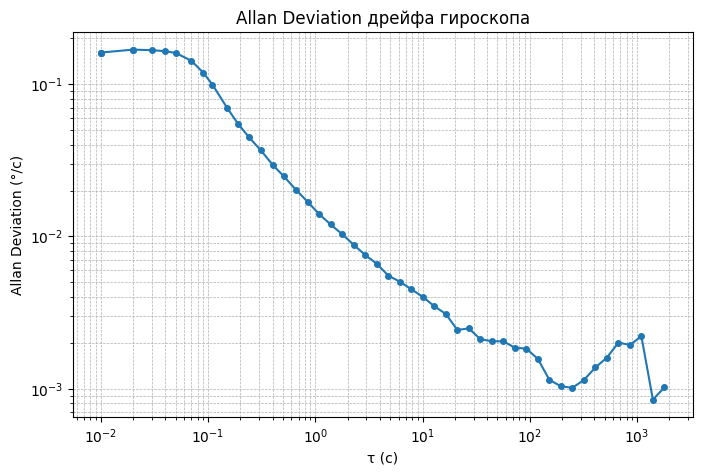

In [ ]:
# 2.6. Вычисляем Allan deviation для временного ряда rate
times = dr['time'].values
rates = dr['rate'].values
dt = np.mean(np.diff(times))  # предполагаем, что шаг равен среднему при одинаковом дискретизации

taus, adev = allan_deviation(rates - np.mean(rates), dt)

# Строим график Allan deviation в лог-лог масштабе
plt.figure(figsize=(8, 5))
plt.loglog(taus, adev, 'o-', markersize=4)
plt.xlabel('τ (с)')
plt.ylabel('Allan Deviation (°/с)')
plt.title('Allan Deviation дрейфа гироскопа')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()


#### 2.8. Извлечение параметров ARW, Bias Instability и RRW

**4. Основные шумовые составляющие (IEEE 1431)**  
- **ARW (Angular Random Walk):** наклон $-1/2$ на малых $\tau$, белый шум.  
- **Bias Instability:** плоская зона, минимум $\sigma(\tau)$.  
- **Rate Random Walk (RRW):** наклон $+1/2$ на больших $\tau$, медленный дрейф.


1. **ARW (Angle Random Walk):**  
   Оценивается как значение 
   $(\sigma(τ)) при (τ = 1)$

   $ARW = \sigma(1\,\text{с}). $

2. **Bias Instability:**  
   Это минимальное значение $\sigma(τ)$ на аппроксимированной или исходной кривой.

3. **Rate Random Walk (RRW):**  
   На больших τ область с наклоном $+\tfrac{1}{2}$. RRW можно оценить, взяв значение $\sigma(τ)$ при $τ = 3600$ с и разделив на $\sqrt{τ}$:  
   $\; RRW = \frac{\sigma(τ)}{\sqrt{τ}}.$

**5. Модель аппроксимации**  
По IEEE 1431 девиацию Аллана аппроксимируют моделью дисперсии:  
$$
  \mathrm{Var}(\tau)
  = \frac{K^2\,\tau}{3}
  + B^2 \,\frac{2 \ln 2}{\pi}
  + \frac{N^2}{\tau},
$$  
где  
- $K$ — параметр белого шума (ARW),  
- $B$ — параметр Bias Instability,  
- $N$ — параметр Rate Random Walk.  

Соответственно,  
$$
  \sigma(\tau) = \sqrt{\mathrm{Var}(\tau)}.
$$

**6. Определение параметров**  
- **ARW ($K$):** значение $\sigma(\tau)$ при $\tau = 1\,$с.  
- **Bias Instability ($B$):** минимальное $\sigma(\tau)$.  
- **RRW ($N$):** из области наклона $+1/2$, часто как $N = \sigma(\tau)/\sqrt{\tau}$ при большом $\tau$.

**7. Практические шаги**  
1. Сформировать массив $\tau$ (логшкала или степени двойки).  
2. Посчитать $\sigma(\tau)$ функцией Allan deviation.  
3. Построить график $\log\tau$–$\log\sigma(\tau)$.  
4. Аппроксимировать моделью IEEE 1431 через метод наименьших квадратов и получить $K$, $B$, $N$.



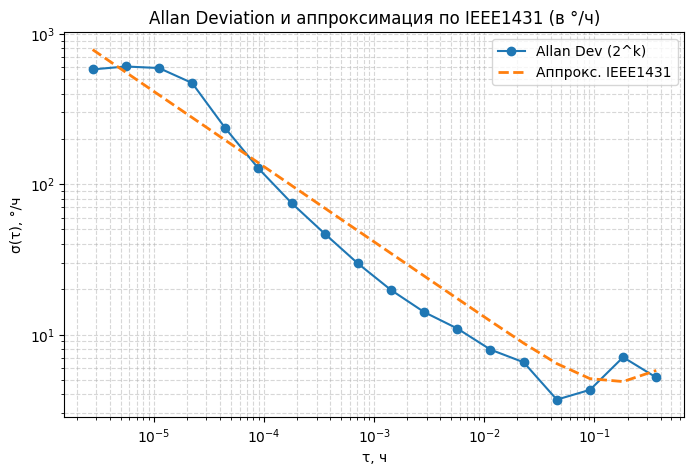

In [ ]:
from scipy.optimize import curve_fit

# Предполагается, что DataFrame dr уже загружен и имеет колонки ['time', 'voltage', 'rate']
# dr['rate'] = (voltage - intercept) / slope

time_d = dr['time'].values       # время в секундах
rate_d = dr['rate'].values       # скорость в °/с

# Шаг дискретизации
T0 = np.mean(np.diff(time_d))    # секунда

# Функция расчёта Allan-девиации для набора τ (в секундах)
def allan_deviation(x, T0, taus):
    N = len(x)
    adev = []
    for tau in taus:
        m = int(np.round(tau / T0))
        if m < 1 or 2*m > N:
            adev.append(np.nan)
            continue
        truncated = x[: m * (N // m)]
        reshaped = truncated.reshape(-1, m)
        y = reshaped.mean(axis=1)
        diffs = np.diff(y)
        var = 0.5 * np.mean(diffs**2)
        adev.append(np.sqrt(var))
    return np.array(adev)

# Модель по IEEE1431, возвращающая σ(τ) для τ в секундах
def variance_model(tau, R, K, B, Np, Q):
    # tau: массив τ в секундах
    n = tau / T0
    term_rw = (K**2 * n * T0) / 3
    term_bias = B**2 * (2/np.pi * np.log(2)) + (Np**2) / (n * T0)
    return np.sqrt(term_rw + term_bias + Q**2)

# Генерация τ по степеням двойки: τ = m * T0, m = 2^k
N = len(rate_d)
max_m = N // 2
k_max = int(np.floor(np.log2(max_m)))
m_values = 2 ** np.arange(0, k_max + 1)
taus_sec = m_values * T0        # τ в секундах

taus_h = taus_sec / 3600        # τ в часах для графика

# Расчёт Allan-девиации
x = rate_d - np.mean(rate_d)
adev = allan_deviation(x, T0, taus_sec)

# Фильтрация NaN для подгонки
mask = ~np.isnan(adev)
taus_sec_fit = taus_sec[mask]
taus_h_fit = taus_h[mask]
adev_fit = adev[mask]

# Начальные приближения для [R, K, B, Np, Q]
initial_guess = [1e-5, 1e-4, 1e-3, 1e-4, 1e-5]

# Поиск оптимальных параметров
popt, pcov = curve_fit(
    variance_model,
    taus_sec_fit,
    adev_fit,
    p0=initial_guess,
    bounds=(0, np.inf),
    maxfev=10000
)

adev_h       = adev * 3600.0
model_adev_h = model_adev * 3600.0

# 2) Строим график с τ в часах и σ в °/ч
plt.figure(figsize=(8, 5))
plt.loglog(taus_h, adev_h, 'o-', markersize=6, label='Allan Dev (2^k)')
plt.loglog(taus_h, model_adev_h, '--', linewidth=2, label='Аппрокс. IEEE1431')

plt.xlabel('τ, ч')
plt.ylabel('σ(τ), °/ч')
plt.title('Allan Deviation и аппроксимация по IEEE1431 (в °/ч)')
plt.grid(which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


In [ ]:

V0_mk_mV = V0_mk * 1000
print(f"Смещение нуля по MK в мВ:      {V0_mk_mV:.3f} мВ")
voltage_offset_drift_V = bias_zero_drift * slope
voltage_offset_drift_mV = voltage_offset_drift_V * 1000
print(f"Смещение нуля по дрейфу в мВ:  {voltage_offset_drift__mV:.3f} мВ")


Смещение нуля по MK в мВ:      2509.595 мВ
Смещение нуля по дрейфу в мВ:  2551.010 мВ


In [ ]:
print(f"Масштабный коэффициент (по ~10% центральных скоростей): {scale_factor_mV_per_dps:.3f} мВ/(°/с)")
print(f"Несимметричность МК: {asym:.3f} %")
print(f"Тренд дрейфа: {trend_dph2:.6f} °/ч/ч")

print("Оптимизированные параметры модели IEEE1431:")
print(f"ARW (K)                 = {K_opt:.3e} °/√s")
print(f"Bias Instability (B)    = {B_opt:.3e} °/с")
print(f"Rate Random Walk (Np)   = {Np_opt:.3e} °/с/√Hz")
print(f"Доп.шум (Q)             = {Q_opt:.3e} °/с")
print(f"(R параметр неинтерпретирован)= {R_opt:.3e}")

Масштабный коэффициент (по ~10% центральных скоростей): -6.219 мВ/(°/с)
Несимметричность МК: 0.004 %
Смещение нуля (Bias_0) по малому участку: -0.007273 °/с
Смещение нуля по дрейфу: -0.047079 °/с
Тренд дрейфа: -8.145627 °/ч/ч
Оптимизированные параметры модели IEEE1431:
ARW (K)                 = 5.902e-05 °/√s
Bias Instability (B)    = 6.645e-05 °/с
Rate Random Walk (Np)   = 2.365e-02 °/с/√Hz
Доп.шум (Q)             = 6.189e-05 °/с
(R параметр неинтерпретирован)= 1.000e-05
